In [1]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
path

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


'/kaggle/input/chest-xray-pneumonia'

In [2]:
import os
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

chest-xray-pneumonia/
  chest_xray/
    chest_xray/
    __MACOSX/
    val/
    test/
    train/


In [3]:
DATA_ROOT = os.path.join(path, "chest_xray")
if not os.path.isdir(DATA_ROOT):
    # some copies of the dataset nest everything under chest_xray/chest_xray
    for root, dirs, _ in os.walk(path):
        if "chest_xray" in dirs:
            DATA_ROOT = os.path.join(root, "chest_xray")
            break

print("DATA_ROOT:", DATA_ROOT)

SPLITS = ["train", "val", "test"]

for split in SPLITS:
    split_path = os.path.join(DATA_ROOT, split)
    if os.path.isdir(split_path):
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                n = len([f for f in os.listdir(cls_path) if not f.startswith(".")])
                print(f"{split}/{cls}: {n} images")

DATA_ROOT: /kaggle/input/chest-xray-pneumonia/chest_xray
train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


In [4]:
# Step 1: remove non-image files (hidden files, wrong extensions)
VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp")
removed_non_image = 0

for split in SPLITS:
    split_path = os.path.join(DATA_ROOT, split)
    if not os.path.isdir(split_path):
        continue
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            if not fname.lower().endswith(VALID_EXT):
                os.remove(fpath)
                removed_non_image += 1

print("Non-image files removed:", removed_non_image)

Non-image files removed: 0


In [5]:
# Step 2: detect and remove corrupted images
# Standard approach: try to fully load the image (not just verify()),
# since verify() alone can miss some truncated/corrupted JPEGs.
from PIL import Image

corrupted_files = []

for split in SPLITS:
    split_path = os.path.join(DATA_ROOT, split)
    if not os.path.isdir(split_path):
        continue
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
                with Image.open(fpath) as img:
                    img.load()
            except Exception:
                corrupted_files.append(fpath)

print("Corrupted images found:", len(corrupted_files))

for f in corrupted_files:
    os.remove(f)

print("Corrupted images removed.")

Corrupted images found: 0
Corrupted images removed.


In [6]:
# Step 3: inspect image properties (mode, size) to catch anomalies
import random
from collections import Counter

modes = Counter()
sizes = []

sample_paths = []
for split in SPLITS:
    split_path = os.path.join(DATA_ROOT, split)
    if not os.path.isdir(split_path):
        continue
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            sample_paths.append(os.path.join(cls_path, fname))

random.seed(42)
inspected = random.sample(sample_paths, min(500, len(sample_paths)))

for fpath in inspected:
    with Image.open(fpath) as img:
        modes[img.mode] += 1
        sizes.append(img.size)

print("Image modes (sample of 500):", modes)
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f"Width  -> min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)/len(widths):.0f}")
print(f"Height -> min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)/len(heights):.0f}")

Image modes (sample of 500): Counter({'L': 472, 'RGB': 28})
Width  -> min: 400, max: 2572, avg: 1311
Height -> min: 138, max: 2570, avg: 962


In [7]:
# Step 4: check class balance after cleaning
import pandas as pd

counts = []
for split in SPLITS:
    split_path = os.path.join(DATA_ROOT, split)
    if not os.path.isdir(split_path):
        continue
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXT)])
            counts.append({"split": split, "class": cls, "count": n})

df_counts = pd.DataFrame(counts)
df_counts

,split,class,count
0,train,PNEUMONIA,3875
1,train,NORMAL,1341
2,val,PNEUMONIA,8
3,val,NORMAL,8
4,test,PNEUMONIA,390
5,test,NORMAL,234


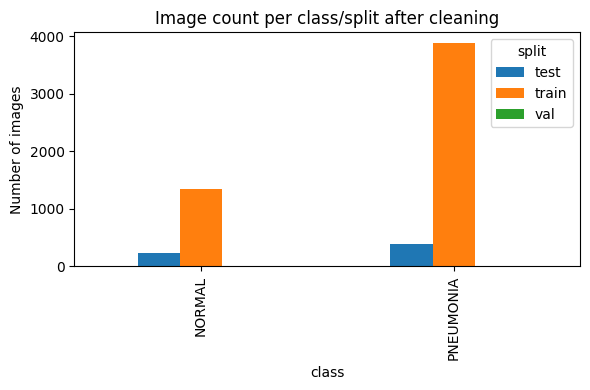

In [8]:
import matplotlib.pyplot as plt
pivot = df_counts.pivot(index="class", columns="split", values="count").fillna(0)
pivot.plot(kind="bar", figsize=(6, 4))
plt.title("Image count per class/split after cleaning")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

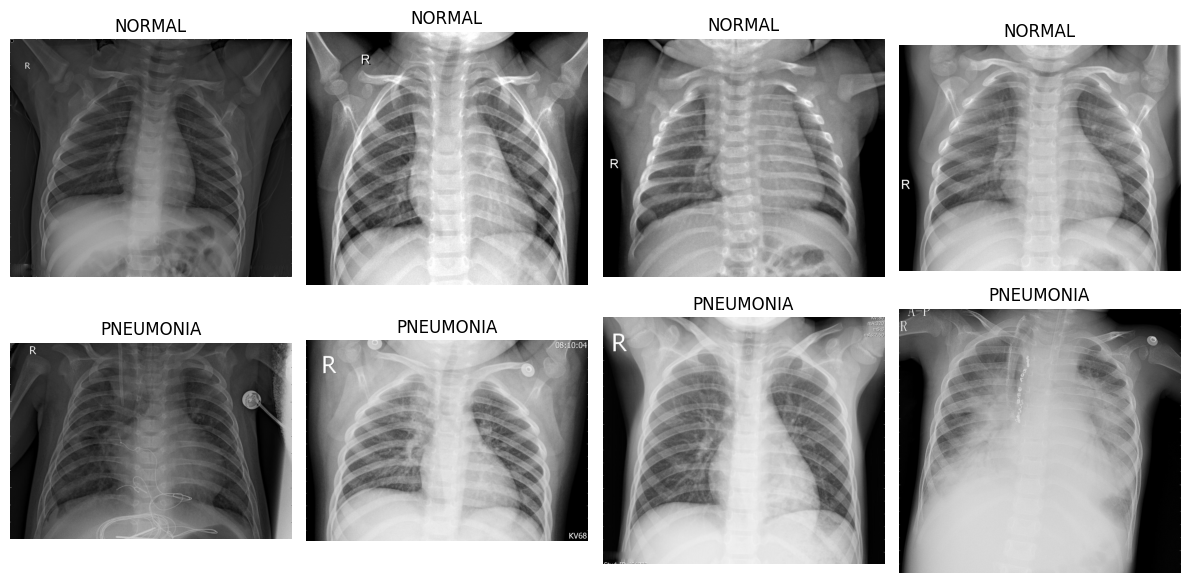

In [9]:
# Step 6: visualize a few sample images per class (sanity check)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    cls_path = os.path.join(DATA_ROOT, "train", cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXT)][:4]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(cls_path, fname))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [10]:
pip install split-folders -q

In [11]:
import shutil

MERGED_DIR = "/home/claude/chest_xray_merged"
if os.path.isdir(MERGED_DIR):
    shutil.rmtree(MERGED_DIR)
os.makedirs(MERGED_DIR, exist_ok=True)

classes = set()
for split in SPLITS:
    split_path = os.path.join(DATA_ROOT, split)
    if os.path.isdir(split_path):
        for cls in os.listdir(split_path):
            if os.path.isdir(os.path.join(split_path, cls)):
                classes.add(cls)

for cls in classes:
    os.makedirs(os.path.join(MERGED_DIR, cls), exist_ok=True)

for split in SPLITS:
    split_path = os.path.join(DATA_ROOT, split)
    if not os.path.isdir(split_path):
        continue
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            src = os.path.join(cls_path, fname)
            dst = os.path.join(MERGED_DIR, cls, f"{split}_{fname}")
            shutil.copy2(src, dst)

for cls in classes:
    n = len(os.listdir(os.path.join(MERGED_DIR, cls)))
    print(f"{cls}: {n} images (after merging)")

PNEUMONIA: 4273 images (after merging)
NORMAL: 1583 images (after merging)


In [12]:
import splitfolders

output_folder = "/home/claude/ChestXrayDataset"

splitfolders.ratio(
    MERGED_DIR,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 5856 files [00:09, 642.65 files/s]


In [13]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(output_folder, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(output_folder, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(output_folder, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 4099 files belonging to 2 classes.
Found 877 files belonging to 2 classes.
Found 880 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [14]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [15]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [16]:
from tensorflow.keras import layers, Model

inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.efficientnet.preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [17]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 99s 336ms/step - accuracy: 0.8556 - loss: 0.3261 - val_accuracy: 0.9293 - val_loss: 0.1937
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9141 - loss: 0.2094 - val_accuracy: 0.9373 - val_loss: 0.1687
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9275 - loss: 0.1836 - val_accuracy: 0.9453 - val_loss: 0.1571
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9358 - loss: 0.1631 - val_accuracy: 0.9510 - val_loss: 0.1388
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9373 - loss: 0.1587 - val_accuracy: 0.9544 - val_loss: 0.1307
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9429 - loss: 0.1477 - val_accuracy: 0.9567 - val_loss: 0.1254
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9427 - loss: 0.1475 - val_accuracy: 0.9590 - val_loss: 0.1223
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9432 - loss: 0.1466 - val_ac

In [19]:
model.evaluate(test_ds)

28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 606ms/step - accuracy: 0.9386 - loss: 0.1551


[0.15514950454235077, 0.9386363625526428]

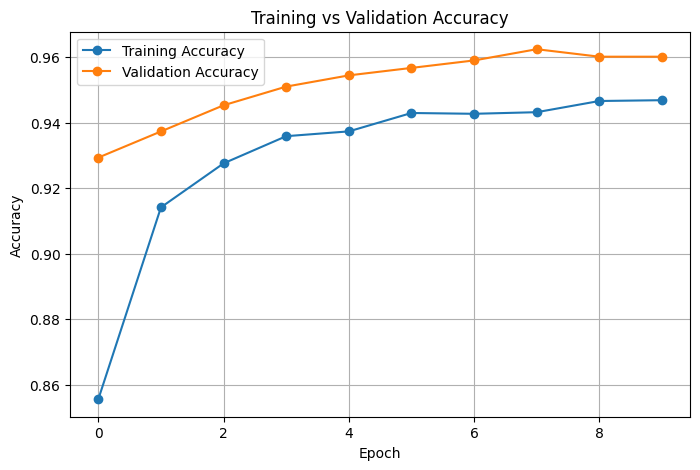

In [31]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

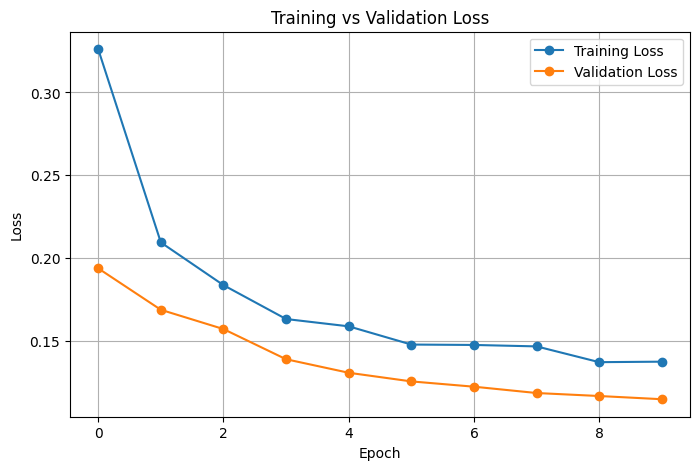

In [32]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 60s 243ms/step - accuracy: 0.9027 - loss: 0.2560 - val_accuracy: 0.9578 - val_loss: 0.1338
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9246 - loss: 0.2001 - val_accuracy: 0.9567 - val_loss: 0.1308
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9366 - loss: 0.1757 - val_accuracy: 0.9612 - val_loss: 0.1250
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9405 - loss: 0.1622 - val_accuracy: 0.9624 - val_loss: 0.1178
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9488 - loss: 0.1464 - val_accuracy: 0.9635 - val_loss: 0.1126
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9522 - loss: 0.1389 - val_accuracy: 0.9647 - val_loss: 0.1090
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9505 - loss: 0.1308 - val_accuracy: 0.9669 - val_loss: 0.1058
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9549 - loss: 0.1228 - val_ac

In [22]:
model.evaluate(test_ds)

28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step - accuracy: 0.9466 - loss: 0.1414


[0.1414473056793213, 0.9465909004211426]

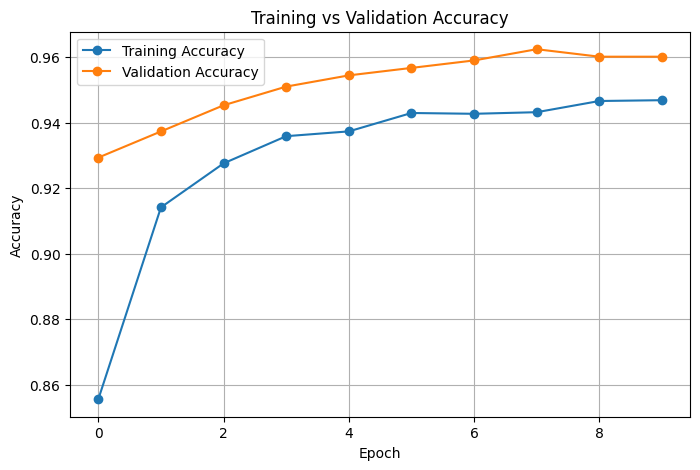

In [29]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

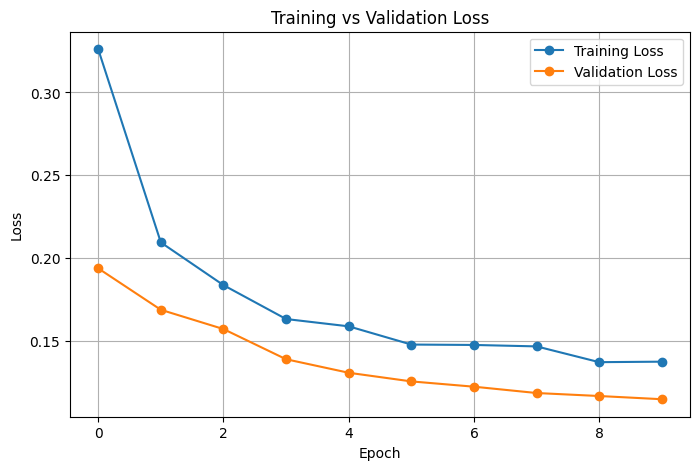

In [30]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [23]:
model.save("chest_xray_classifier.keras")

In [24]:
import numpy as np
import glob

sample_files = glob.glob(os.path.join(output_folder, "test", "PNEUMONIA", "*"))
sample_path = sample_files[0]

img = tf.keras.utils.load_img(
    sample_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("File:", sample_path)
print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
File: /home/claude/ChestXrayDataset/test/PNEUMONIA/train_person1469_bacteria_3824.jpeg
Prediction: PNEUMONIA
